### Importar librerías

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
plt.style.use('ggplot') # Estilo ggplot

### Dataset

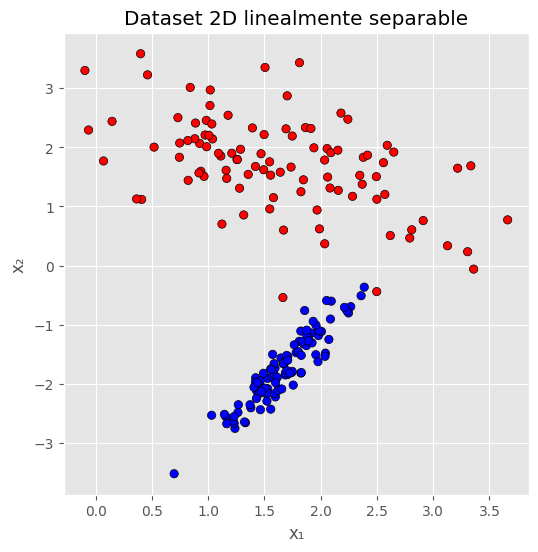

In [ ]:
# Generar datos
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.7,       # cuanto mayor, más separable
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Graficar
plt.figure(figsize=(6, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k')
plt.title("Dataset 2D linealmente separable")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(True)
plt.show()

## Perceptrón

In [ ]:
def step(x):
    out = np.where(x >= 0, 1, 0).squeeze()
    return out

In [ ]:
def check_coincidences(y_true, y_pred, X):
    comparation = (y_true == y_pred)  # Verifica si etiqueta real es igual a prediccion
    idx_unequal = np.where(~comparation)[0]  # Obtiene indices donde hay diferencias
    if len(idx_unequal) != 0:
        X_e = X[idx_unequal[0]] # Obtiene el primer valor de X donde hay una diferencia (mal clasificado)
    else:
        X_e = None
    return X_e, idx_unequal

In [ ]:
def update_parameters(y_true, y_pred, X_e, idx_unequal, W, b, alpha=0.1):
    # Actualizamos pesos con regla de aprendizaje
    error = y_true[idx_unequal[0]] - y_pred[idx_unequal[0]]
    W[0] = W[0] + alpha * error * X_e[0]
    W[1] = W[1] + alpha * error * X_e[1]
    b = b + alpha * error
    return error, W, b


In [ ]:
def visualize_decision_boundary(X,y,W,b,x_min=-5,x_max=5):
    x_vals = np.linspace(-7, 7, 100)
    y_vals = -(b + W[0]*x_vals) / W[1]
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
    plt.plot(x_vals, y_vals, 'k--')
    plt.title("Frontera de decisión del perceptrón")
    plt.show()

### Inicialización de pesos aleatorios

In [ ]:
# Inicialización de pesos aleatorios
np.random.seed(14)
W = np.random.rand(2)
b = np.random.rand(1)

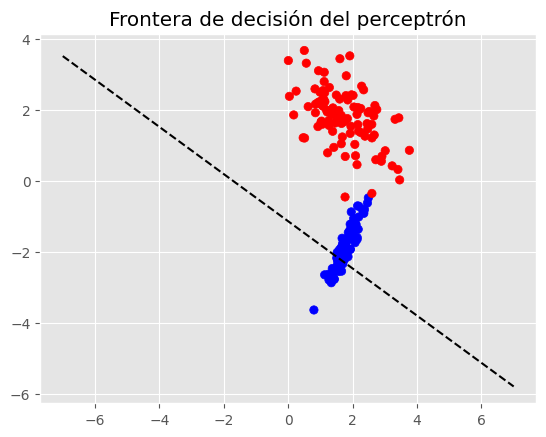

In [ ]:
# Visualización de frontera de decisión con parámetros sin entrenar
visualize_decision_boundary(X_train,y_train,W,b,x_min=0,x_max=1)

### Entrenamiento

In [ ]:
clasificacion = True
i = 0
mistake = 10000000000000

while clasificacion:
    # Feed forward
    a = np.matmul(X_train, W) + b
    y_pred = step(a)

    # Verificar coincidencias
    X_e, idx_unequal = check_coincidences(y_train, y_pred, X_train)

    # Criterio de parada
    if X_e is None:
        print(f"Convergió en la época {i}")
        print(f"Pesos finales: {W}, bias: {b}")
        clasificacion = False

    else:
        # Actualizar parámetros
        error, W, b = update_parameters(y_train, y_pred, X_e, idx_unequal, W, b)
        if error <= mistake:
            mistake = error
            best_W = W
            best_b = b
            print(f"Pesos : {W}, bias: {b}, mistake: {error}")
        i = i + 1
        if i > 1000:  # límite por seguridad
            print("No converge tras 1000 iteraciones.")
            break

Pesos : [0.03533363 1.11064248], bias: [0.87042769], mistake: 1
Pesos : [-0.17408062  1.17088982], bias: [0.77042769], mistake: -1
Pesos : [-0.21705341  1.17700589], bias: [0.77042769], mistake: -1
Pesos : [-0.26002619  1.18312196], bias: [0.77042769], mistake: -1
Pesos : [-0.29886862  1.18819761], bias: [0.77042769], mistake: -1
Pesos : [-0.37115691  1.17062696], bias: [0.77042769], mistake: -1
Pesos : [-0.24768822  1.12261176], bias: [0.87042769], mistake: -1
Pesos : [-0.290661    1.12872784], bias: [0.87042769], mistake: -1
Pesos : [-0.33363379  1.13484391], bias: [0.87042769], mistake: -1
Pesos : [-0.40592208  1.11727326], bias: [0.87042769], mistake: -1
Pesos : [-0.28245339  1.06925806], bias: [0.97042769], mistake: -1
Pesos : [-0.32542617  1.07537414], bias: [0.97042769], mistake: -1
Pesos : [-0.36839896  1.08149021], bias: [0.97042769], mistake: -1
Pesos : [-0.41137174  1.08760628], bias: [0.97042769], mistake: -1
Pesos : [-0.48366003  1.07003563], bias: [0.97042769], mistake: -

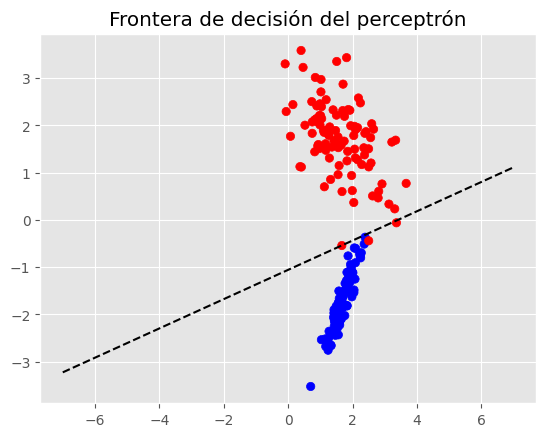

In [ ]:
visualize_decision_boundary(X_train,y_train,W,b,x_min=-5,x_max=3)

### Probar modelo con datos de prueba

In [ ]:
# Feed forward
a = np.matmul(X_test, W) + b
y_pred = step(a)

In [ ]:
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

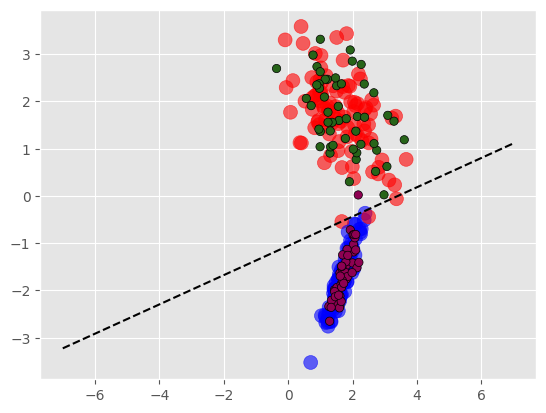

In [ ]:
x_vals = np.linspace(-7, 7, 100)
y_vals = -(b + W[0]*x_vals) / W[1]
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr', s=100,alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='PiYG', edgecolors='k')
plt.plot(x_vals, y_vals, 'k--')

Ejecuta el código proporcionado siguiendo las indicaciones solicitadas y responde las preguntas correspondientes.

En la sección Dataset, modifica el parámetro class_sep de la función make_classification, asignándole el valor 1.0. Posteriormente, vuelve a entrenar el modelo.

Pregunta:
¿Qué ocurre con el perceptrón al realizar este cambio? ¿El modelo logra converger o no?